### compare FMG results between GTDB rs220 vs rs226 using your two summary files:

- 1901_summary_220_k21.csv
- 1901_summary_226_k21.csv

### db location:
- /group/ctbrowngrp5/sourmash-db.new/gtdb-rs226/

### quantify per-sample differences in:

- ref_f_unweighted
- ref_f_weighted
- n_matches

In [11]:
# Load & align the two FMG summaries
import pandas as pd

# load
df220 = pd.read_csv("input-csv/1901_summary_220_k21.csv")
df226 = pd.read_csv("input-csv/1901_summary_226_k21.csv")

# sanity check
print(df220.shape, df226.shape)

# merge on accession
df = df220.merge(
    df226,
    on="accession",
    suffixes=("_220", "_226"),
    how="inner"
)

print("Merged samples:", df.shape[0])

(1901, 4) (1901, 4)
Merged samples: 1901


In [12]:
# Compute per-sample deltas (rs226 − rs220)
for col in ["ref_f_unweighted", "ref_f_weighted", "n_matches"]:
    df[f"delta_{col}"] = df[f"{col}_226"] - df[f"{col}_220"]

df.head()

,accession,ref_f_unweighted_220,ref_f_weighted_220,n_matches_220,ref_f_unweighted_226,ref_f_weighted_226,n_matches_226,delta_ref_f_unweighted,delta_ref_f_weighted,delta_n_matches
0,DRR014782,0.733621,0.949541,12389,0.744218,0.951303,13557,0.010597,0.001762,1168
1,DRR014785,0.728105,0.946977,13328,0.740073,0.949255,14609,0.011969,0.002278,1281
2,DRR019499,0.268765,0.259064,21126,0.297762,0.295750,23740,0.028997,0.036687,2614
3,DRR042462,0.901071,0.965085,3213,0.908685,0.969188,3328,0.007615,0.004102,115
4,DRR042463,0.815821,0.937989,4229,0.827499,0.943272,4517,0.011678,0.005283,288


In [13]:
# Global summary statistics
summary = df[
    ["delta_ref_f_unweighted", "delta_ref_f_weighted", "delta_n_matches"]
].describe()

summary

,delta_ref_f_unweighted,delta_ref_f_weighted,delta_n_matches
count,1901.000000,1901.000000,1901.000000
mean,0.030994,0.022309,2049.334035
std,0.014690,0.028912,2507.331888
min,0.000000,-0.037976,-667.000000
25%,0.021795,0.005747,307.000000
50%,0.030376,0.015956,1032.000000
75%,0.039466,0.030360,2950.000000
max,0.168282,0.435973,21761.000000


In [14]:
# Correlation between rs220 and rs226
corr = df[
    ["ref_f_unweighted_220", "ref_f_unweighted_226",
     "ref_f_weighted_220", "ref_f_weighted_226",
     "n_matches_220", "n_matches_226"]
].corr()

corr

,ref_f_unweighted_220,ref_f_unweighted_226,ref_f_weighted_220,ref_f_weighted_226,n_matches_220,n_matches_226
ref_f_unweighted_220,1.000000,0.997323,0.545618,0.551413,-0.236228,-0.244712
ref_f_unweighted_226,0.997323,1.000000,0.515319,0.528583,-0.217585,-0.226527
ref_f_weighted_220,0.545618,0.515319,1.000000,0.988671,-0.492832,-0.497253
ref_f_weighted_226,0.551413,0.528583,0.988671,1.000000,-0.493975,-0.499347
n_matches_220,-0.236228,-0.217585,-0.492832,-0.493975,1.000000,0.999567
n_matches_226,-0.244712,-0.226527,-0.497253,-0.499347,0.999567,1.000000


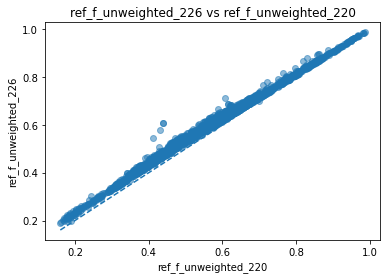

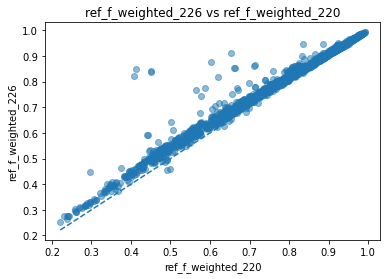

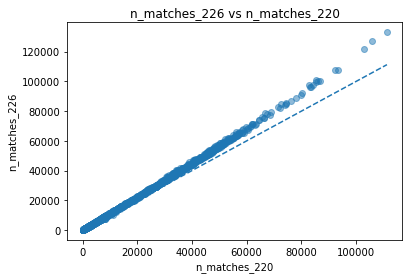

In [15]:
# Scatter plots (rs220 vs rs226)
import matplotlib.pyplot as plt

metrics = [
    ("ref_f_unweighted_220", "ref_f_unweighted_226"),
    ("ref_f_weighted_220", "ref_f_weighted_226"),
    ("n_matches_220", "n_matches_226"),
]

for x, y in metrics:
    plt.figure()
    plt.scatter(df[x], df[y], alpha=0.5)
    plt.plot(
        [df[x].min(), df[x].max()],
        [df[x].min(), df[x].max()],
        linestyle="--"
    )
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{y} vs {x}")
    plt.show()

### Results - ref_f_weighted:

- a tight diagonal with a handful of points well above the 1:1 line. Those are samples where rs226 substantially increased ref_f_weighted relative to rs220.
- interpretation of significant outliers (from experience of GTDB updates), indicating these samples typically have:
    - Previously underrepresented lineages
    - Strong strain-level novelty
    - Large increases in reference availability in rs226
    - Often low–mid coverage samples, not the highest ones
- “A small subset of samples exhibited large deviations from the identity line, indicating substantial gains in weighted reference coverage following the GTDB rs226 update. These samples likely benefit disproportionately from expanded taxonomic representation in the newer database.”

In [25]:
# to identify those samples
# Simple & transparent: Δ threshold, compute the difference and flag samples above a cutoff.

# delta
df["delta_ref_f_weighted"] = (
    df["ref_f_weighted_226"] - df["ref_f_weighted_220"]
)

# inspect distribution
df["delta_ref_f_weighted"].describe()

# Pick a biologically meaningful threshold, e.g. +0.1
# >10% absolute increase in weighted reference fraction were considered strongly affected by database update
outliers = df[df["delta_ref_f_weighted"] > 0.1]

outliers[[
    "accession",
    "ref_f_weighted_220",
    "ref_f_weighted_226",
    "delta_ref_f_weighted"
]].sort_values("delta_ref_f_weighted", ascending=False)

,accession,ref_f_weighted_220,ref_f_weighted_226,delta_ref_f_weighted
1801,SRR6519255,0.413994,0.849966,0.435973
1800,SRR6519254,0.406637,0.822574,0.415937
1799,SRR6519253,0.451619,0.841099,0.389480
1802,SRR6519256,0.451791,0.839109,0.387317
1549,SRR3961739,0.603135,0.875146,0.272011
706,ERR3285537,0.653213,0.912721,0.259508
1441,SRR2107181,0.564918,0.768635,0.203717
1321,SRR1702226,0.619821,0.817210,0.197388
597,ERR2762114,0.661156,0.852464,0.191308
598,ERR2762115,0.662751,0.851416,0.188665


In [26]:
print(len(outliers))

22


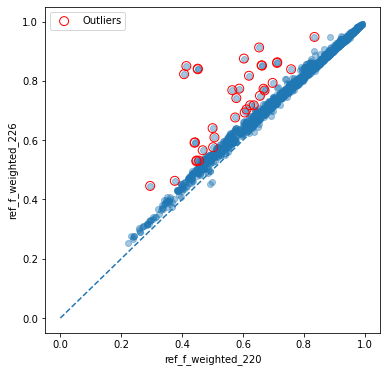

In [10]:
# Annotate them directly on your scatter (high impact)
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.4)

# highlight outliers
plt.scatter(
    outliers["ref_f_weighted_220"],
    outliers["ref_f_weighted_226"],
    edgecolor="red",
    facecolor="none",
    s=80,
    label="Outliers"
)

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("ref_f_weighted_220")
plt.ylabel("ref_f_weighted_226")
plt.legend()
plt.show()

## Workflow below to (1) annotate outliers with biome, and (2) test whether biome is associated with being an outlier.

In [7]:
# Load biome-annotated FMG file
import pandas as pd

biome_df = pd.read_csv("../analysis_rs226_k21/join_rs226_k21.csv")

biome_df.head()

,accession,ref_f_unweighted,ref_f_weighted,n_matches,biome3
0,DRR014782,0.733621,0.949541,12389,Host-associated:Mammals:Respiratory system
1,DRR014785,0.728105,0.946977,13328,Host-associated:Mammals:Respiratory system
2,DRR019499,0.268765,0.259064,21126,Host-associated:Insecta:Digestive system
3,DRR042462,0.901071,0.965085,3213,Host-associated:Human:Digestive system
4,DRR042463,0.815821,0.937989,4229,Host-associated:Human:Digestive system


In [13]:
# Join biome info onto your rs220 vs rs226 comparison
df = df.merge(
    biome_df[["accession", "biome3"]],
    on="accession",
    how="left"
)

df["biome3"].value_counts().head(10)

Host-associated:Mammals:Gastrointestinal tract    289
Host-associated:Animal:Digestive system           239
Engineered:Wastewater:Water and sludge            221
Host-associated:Human:Digestive system            155
Host-associated:Birds:Digestive system            124
Host-associated:Insecta:Digestive system          122
Environmental:Aquatic:Thermal springs             104
Environmental:Aquatic:Marine                      101
Host-associated:Human:Skin                         65
Environmental:Aquatic:Freshwater                   64
Name: biome3, dtype: int64

In [22]:
# Extract biome for the outliers
outliers = df[df["delta_ref_f_weighted"] > 0.1]   # or your chosen rule

outliers_biomes = (
    outliers["biome3"]
    .value_counts()
    .rename("outlier_count")
    .reset_index()
    .rename(columns={"index": "biome3"})
)

outliers_biomes

,biome3,outlier_count
0,Environmental:Aquatic:Thermal springs,7
1,Engineered:Wastewater:Activated Sludge,4
2,Environmental:Aquatic:Freshwater,3
3,Environmental:Aquatic:Non-marine Saline and Al...,2
4,Environmental:Aquatic:Marine,2
5,Host-associated:Mammals:Gastrointestinal tract,1
6,Host-associated:Insecta:Digestive system,1
7,Environmental:Aquatic:Sediment,1
8,Engineered:Wastewater:Industrial wastewater,1


In [23]:
len(outliers)

22

In [17]:
# Statistical test: is biome associated with being an outlier?
# Collapse to top-level biome (optional)
df["biome1"] = df["biome3"].str.split(":").str[0]

# Build contingency table
df["is_outlier"] = df["delta_ref_f_weighted"] > 0.1

contingency = pd.crosstab(df["biome1"], df["is_outlier"])
contingency

# Chi-square test
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency)
chi2, p

# Interpretation
# p < 0.05 → biome composition differs significantly for outliers
# p ≥ 0.05 → no strong biome association

(34.20847742648753, 3.730126065137522e-08)

In [18]:
# Effect size: which biomes shift the most?
# This gives the fraction of samples in each biome that are outliers

effect = (
    contingency
    .assign(outlier_rate=lambda x: x[True] / x.sum(axis=1))
    .sort_values("outlier_rate", ascending=False)
)

effect

is_outlier,False,True,outlier_rate
biome1,,,
Environmental,375,15,0.038462
Engineered,377,5,0.013089
Host-associated,1127,2,0.001771


## color code outliers circle based on biome1 type

In [27]:
# "Host-associated": "#1f77b4", "Engineered": "#ff7f0e", "Environmental": "#2ca02c"
# Make sure biome1 exists and define biome → color mapping

df["biome1"] = df["biome3"].str.split(":").str[0]
outliers = df[df["delta_ref_f_weighted"] > 0.1]

biome_colors = {
    "Host-associated": "#1f77b4",   # blue
    "Engineered": "#ff7f0e",         # orange
    "Environmental": "#2ca02c",      # green
}

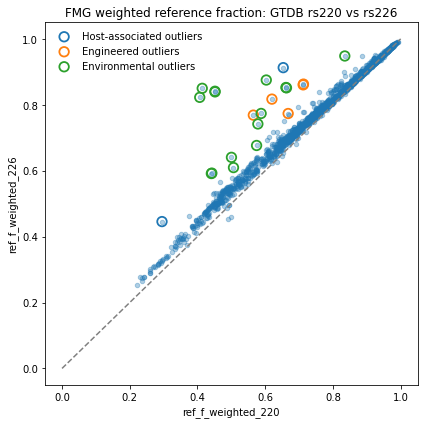

In [28]:
# Plot with biome-colored outlier rings

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

# background points
plt.scatter(
    df["ref_f_weighted_220"],
    df["ref_f_weighted_226"],
    alpha=0.35,
    s=20
)

# plot outliers by biome
for biome, color in biome_colors.items():
    subset = outliers[outliers["biome1"] == biome]
    if subset.empty:
        continue

    plt.scatter(
        subset["ref_f_weighted_220"],
        subset["ref_f_weighted_226"],
        edgecolor=color,
        facecolor="none",
        s=90,
        linewidth=1.8,
        label=f"{biome} outliers"
    )

# identity line
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("ref_f_weighted_220")
plt.ylabel("ref_f_weighted_226")
plt.legend(frameon=False)
plt.title("FMG weighted reference fraction: GTDB rs220 vs rs226")

plt.tight_layout()
plt.show()

### - Updating the FMG reference database from GTDB rs220 to rs226 produces largely concordant results overall, but yields substantial gains in weighted reference fraction for a small subset of samples, particularly from environmental aquatic and engineered biomes.
### - Figure X. Comparison of FMG weighted reference fraction using GTDB rs220 and rs226.
- Each point represents one metagenomic sample. The dashed line indicates equality between database releases. Most samples fall near the identity line, indicating strong concordance between database versions. A small subset of samples (circled) exhibit large increases in weighted reference fraction under rs226. Outliers are colored by top-level biome category. These samples are enriched in environmental aquatic and engineered systems, consistent with improved reference coverage for previously underrepresented lineages in the rs226 release.

#### Outliers usually mean:
- Previously underrepresented lineages
- Strong strain-level novelty
- Large increases in reference availability in rs226
- Often low–mid coverage samples, not the highest ones
“A small subset of samples exhibited large deviations from the identity line, indicating substantial gains in weighted reference coverage following the GTDB rs226 update. These samples likely benefit disproportionately from expanded taxonomic representation in the newer database.”


In [32]:
# list out info for these outliers, biome and outlie value
outlier_table = (
    outliers[[
        "accession",
        "biome3",
        "biome1",
        "ref_f_weighted_220",
        "ref_f_weighted_226",
        "delta_ref_f_weighted"
    ]]
    .sort_values("delta_ref_f_weighted", ascending=False)
)

outlier_table

,accession,biome3,biome1,ref_f_weighted_220,ref_f_weighted_226,delta_ref_f_weighted
1801,SRR6519255,Environmental:Aquatic:Thermal springs,Environmental,0.413994,0.849966,0.435973
1800,SRR6519254,Environmental:Aquatic:Thermal springs,Environmental,0.406637,0.822574,0.415937
1799,SRR6519253,Environmental:Aquatic:Thermal springs,Environmental,0.451619,0.841099,0.389480
1802,SRR6519256,Environmental:Aquatic:Thermal springs,Environmental,0.451791,0.839109,0.387317
1549,SRR3961739,Environmental:Aquatic:Thermal springs,Environmental,0.603135,0.875146,0.272011
706,ERR3285537,Host-associated:Mammals:Gastrointestinal tract,Host-associated,0.653213,0.912721,0.259508
1441,SRR2107181,Engineered:Wastewater:Activated Sludge,Engineered,0.564918,0.768635,0.203717
1321,SRR1702226,Engineered:Wastewater:Industrial wastewater,Engineered,0.619821,0.817210,0.197388
597,ERR2762114,Environmental:Aquatic:Marine,Environmental,0.661156,0.852464,0.191308
598,ERR2762115,Environmental:Aquatic:Marine,Environmental,0.662751,0.851416,0.188665


In [35]:
len(outlier_table)

22

### Join these outliers to n_matches deltas Check whether they correlate with low original coverage

In [27]:
df["delta_n_matches"] = df["n_matches_226"] - df["n_matches_220"]
outliers = df[df["delta_ref_f_weighted"] > 0.1]
print (outliers)

        accession  ref_f_unweighted_220  ref_f_weighted_220  n_matches_220  \
27     ERR1201173              0.470640            0.506321          14340   
308    ERR2407577              0.391141            0.440972          44268   
309    ERR2407578              0.396218            0.442361          45092   
597    ERR2762114              0.405373            0.661156          14993   
598    ERR2762115              0.361532            0.662751          29727   
706    ERR3285537              0.390511            0.653213            936   
736    ERR3478706              0.458652            0.587906          42089   
737    ERR3478716              0.372843            0.578250          20366   
1039  SRR10838798              0.455821            0.295191           4556   
1276   SRR1572169              0.400600            0.500318          33023   
1321   SRR1702226              0.588814            0.619821          12116   
1344   SRR1763381              0.537480            0.667714     

### Export this table, add n_matches deltas, trace which genomes drive these gains

In [36]:
# Export the outlier table
outlier_table = (
    outliers.assign(
        delta_ref_f_weighted=lambda x: x["ref_f_weighted_226"] - x["ref_f_weighted_220"],
        delta_n_matches=lambda x: x["n_matches_226"] - x["n_matches_220"]
    )[[
        "accession",
        "biome1",
        "biome3",
        "ref_f_weighted_220",
        "ref_f_weighted_226",
        "delta_ref_f_weighted",
        "n_matches_220",
        "n_matches_226",
        "delta_n_matches"
    ]]
    .sort_values("delta_ref_f_weighted", ascending=False)
)
outlier_table.to_csv("fmg_rs226_outliers.csv", index=False)
outlier_table.to_csv("fmg_rs226_outliers.tsv", sep="\t", index=False)

In [37]:
# Add n_matches deltas
# delta_ref_f_weighted → coverage gain
# delta_n_matches → reference breadth gain

outlier_table[[
    "accession",
    "delta_ref_f_weighted",
    "delta_n_matches"
]].head(10)

,accession,delta_ref_f_weighted,delta_n_matches
1801,SRR6519255,0.435973,-334
1800,SRR6519254,0.415937,-147
1799,SRR6519253,0.389480,-611
1802,SRR6519256,0.387317,-667
1549,SRR3961739,0.272011,-610
706,ERR3285537,0.259508,131
1441,SRR2107181,0.203717,2356
1321,SRR1702226,0.197388,222
597,ERR2762114,0.191308,889
598,ERR2762115,0.188665,2971


In [ ]:
# Trace which genomes likely drive these gains (FMG-level)
# rs226 introduces new GTDB species / strains that recruit k-mers previously unmatched.
# Are gains driven by more references or better weighting?
# High correlation → gains driven by new genomes added
# Low correlation → gains driven by better weighting of existing matches
outlier_table[[
    "delta_ref_f_weighted",
    "delta_n_matches"
]].corr()

In [38]:
# Flag samples where coverage gain is disproportionate
# These samples likely reflect:
    # - Strain consolidation
    # - Improved genome completeness in rs226
    # - Better taxonomic placement rather than raw DB growth
outlier_table["gain_per_match"] = (
    outlier_table["delta_ref_f_weighted"] /
    outlier_table["delta_n_matches"].replace(0, pd.NA)
)

outlier_table.sort_values("gain_per_match", ascending=False).head(10)

,accession,biome1,biome3,ref_f_weighted_220,ref_f_weighted_226,delta_ref_f_weighted,n_matches_220,n_matches_226,delta_n_matches,gain_per_match
706,ERR3285537,Host-associated,Host-associated:Mammals:Gastrointestinal tract,0.653213,0.912721,0.259508,936,1067,131,0.001981
1547,SRR3961733,Environmental,Environmental:Aquatic:Thermal springs,0.834997,0.948077,0.113080,9051,9172,121,0.000935
1321,SRR1702226,Engineered,Engineered:Wastewater:Industrial wastewater,0.619821,0.817210,0.197388,12116,12338,222,0.000889
1039,SRR10838798,Host-associated,Host-associated:Insecta:Digestive system,0.295191,0.445574,0.150383,4556,5122,566,0.000266
597,ERR2762114,Environmental,Environmental:Aquatic:Marine,0.661156,0.852464,0.191308,14993,15882,889,0.000215
1434,SRR2107133,Engineered,Engineered:Wastewater:Activated Sludge,0.712048,0.860458,0.148410,18712,19518,806,0.000184
1433,SRR2107128,Engineered,Engineered:Wastewater:Activated Sludge,0.712939,0.862726,0.149787,19653,20645,992,0.000151
27,ERR1201173,Environmental,Environmental:Aquatic:Freshwater,0.506321,0.609441,0.103120,14340,15452,1112,0.000093
1441,SRR2107181,Engineered,Engineered:Wastewater:Activated Sludge,0.564918,0.768635,0.203717,23757,26113,2356,0.000086
737,ERR3478716,Environmental,Environmental:Aquatic:Freshwater,0.578250,0.741853,0.163603,20366,22696,2330,0.000070


### identify the genomes newly recruited in rs226 vs rs220, for outlier samples
- For each outlier accession
- List genomes matched in rs226 but not rs220
- Quantify how much they contribute
- Summarize patterns across outliers

- assume:
    - have per-genome FMG tables for both databases
    - Filenames encode the accession (or accession is in query_name)
    - rs220 and rs226 FMG outputs are in different directories

In [40]:
# Setup paths and inputs
import pandas as pd
import glob
import os

# directories (adjust as needed)
FMG_220_DIR = "rs220/"
FMG_226_DIR = "../compare_method/rs226/fmg/"

# outlier accessions
outlier_accessions = set(outliers["accession"])

In [41]:
# Helper function: load matched genomes for one sample
def load_matched_genomes(fmg_file):
    df = pd.read_csv(fmg_file)
    return set(df["match_name"].dropna().unique())

In [42]:
# Diff genomes for each outlier sample
records = []

for acc in sorted(outlier_accessions):

    f220 = glob.glob(os.path.join(FMG_220_DIR, f"{acc}*.fmg*.csv"))
    f226 = glob.glob(os.path.join(FMG_226_DIR, f"{acc}*.fmg*.csv"))

    if not f220 or not f226:
        print(f"Missing FMG file for {acc}")
        continue

    g220 = load_matched_genomes(f220[0])
    g226 = load_matched_genomes(f226[0])

    new_genomes = g226 - g220
    lost_genomes = g220 - g226

    records.append({
        "accession": acc,
        "n_rs220": len(g220),
        "n_rs226": len(g226),
        "n_new_rs226": len(new_genomes),
        "n_lost_rs226": len(lost_genomes),
        "new_genomes_rs226": ";".join(sorted(new_genomes))
    })
genome_diff = pd.DataFrame(records)
genome_diff.sort_values("n_new_rs226", ascending=False)

,accession,n_rs220,n_rs226,n_new_rs226,n_lost_rs226,new_genomes_rs226
2,ERR2407578,45092,50740,50740,45092,GCA_000010565.1 Pelotomaculum thermopropionicu...
1,ERR2407577,44268,49841,49841,44268,GCA_000017645.1 Xanthobacter autotrophicus Py2...
17,SRR5247126,41260,47603,47603,41260,GCA_000010565.1 Pelotomaculum thermopropionicu...
6,ERR3478706,42089,46886,46886,42089,GCA_000010565.1 Pelotomaculum thermopropionicu...
9,SRR1572169,33023,38337,38337,33023,GCA_000063525.1 Synechococcus sp. RCC307;GCA_0...
4,ERR2762115,29727,32698,32698,29727,GCA_000008885.1 Wigglesworthia glossinidia end...
14,SRR2107181,23757,26113,26113,23757,GCA_000010565.1 Pelotomaculum thermopropionicu...
11,SRR1763381,22965,24488,24488,22965,GCA_000155695.1 Verrucomicrobiia bacterium DG1...
7,ERR3478716,20366,22696,22696,20366,GCA_000017645.1 Xanthobacter autotrophicus Py2...
12,SRR2107128,19653,20645,20645,19653,GCA_000015545.1 Acidovorax sp. JS42;GCA_000017...


In [43]:
# Attach outlier magnitude + biome (contextualize)
genome_diff = genome_diff.merge(
    outlier_table[[
        "accession",
        "biome1",
        "biome3",
        "delta_ref_f_weighted",
        "delta_n_matches"
    ]],
    on="accession",
    how="left"
)

genome_diff.sort_values("delta_ref_f_weighted", ascending=False)

,accession,n_rs220,n_rs226,n_new_rs226,n_lost_rs226,new_genomes_rs226,biome1,biome3,delta_ref_f_weighted,delta_n_matches
20,SRR6519255,8065,7731,7731,8065,GCA_000163995.1 Campylobacter jejuni subsp. je...,Environmental,Environmental:Aquatic:Thermal springs,0.435973,-334
19,SRR6519254,9051,8904,8904,9051,GCA_000010565.1 Pelotomaculum thermopropionicu...,Environmental,Environmental:Aquatic:Thermal springs,0.415937,-147
18,SRR6519253,8066,7455,7455,8066,GCA_000063505.1 Synechococcus sp. WH 7803;GCA_...,Environmental,Environmental:Aquatic:Thermal springs,0.389480,-611
21,SRR6519256,8162,7495,7495,8162,GCA_000155695.1 Verrucomicrobiia bacterium DG1...,Environmental,Environmental:Aquatic:Thermal springs,0.387317,-667
16,SRR3961739,11023,10413,10413,11023,GCA_000063505.1 Synechococcus sp. WH 7803;GCA_...,Environmental,Environmental:Aquatic:Thermal springs,0.272011,-610
5,ERR3285537,936,1067,1067,936,GCA_000155695.1 Verrucomicrobiia bacterium DG1...,Host-associated,Host-associated:Mammals:Gastrointestinal tract,0.259508,131
14,SRR2107181,23757,26113,26113,23757,GCA_000010565.1 Pelotomaculum thermopropionicu...,Engineered,Engineered:Wastewater:Activated Sludge,0.203717,2356
10,SRR1702226,12116,12338,12338,12116,GCA_000015545.1 Acidovorax sp. JS42;GCA_000017...,Engineered,Engineered:Wastewater:Industrial wastewater,0.197388,222
3,ERR2762114,14993,15882,15882,14993,GCA_000009845.1 Onion yellows phytoplasma OY-M...,Environmental,Environmental:Aquatic:Marine,0.191308,889
4,ERR2762115,29727,32698,32698,29727,GCA_000008885.1 Wigglesworthia glossinidia end...,Environmental,Environmental:Aquatic:Marine,0.188665,2971


In [44]:
# Which genomes recur across outliers? (key insight)
from collections import Counter

all_new = []

for genomes in genome_diff["new_genomes_rs226"]:
    if genomes:
        all_new.extend(genomes.split(";"))

genome_counts = (
    pd.Series(Counter(all_new))
    .rename("n_outliers")
    .reset_index()
    .rename(columns={"index": "genome_id"})
    .sort_values("n_outliers", ascending=False)
)

genome_counts.head(20)

,genome_id,n_outliers
55389,GCF_029892105.1 Kitasatospora sp. GP82,18
7876,GCA_040766885.1 Thermoguttaceae bacterium,17
6285,GCA_035762175.1 Polyangiaceae bacterium,17
3203,GCA_023423895.1 Pseudomonadota bacterium,17
5583,GCA_035262925.1 Kofleriaceae bacterium,16
32430,GCA_035327325.1 Chloroflexaceae bacterium,16
10775,GCF_000601485.1 Chondromyces apiculatus DSM 436,16
30020,GCA_030684355.1 Pseudomonadota bacterium,15
53463,GCF_020103725.1 Hyalangium gracile,15
58141,GCF_040654715.1 Nonomuraea sp. NPDC050643,15


In [45]:
# (Optional but powerful) Weight by FMG contribution
# If FMG files include f_match or median_abund:
def load_genome_stats(fmg_file):
    df = pd.read_csv(fmg_file)
    return df.groupby("match_name")["f_match"].sum()

# Example for one accession:
acc = genome_diff.iloc[0]["accession"]

f226 = glob.glob(os.path.join(FMG_226_DIR, f"{acc}*.csv"))[0]
f220 = glob.glob(os.path.join(FMG_220_DIR, f"{acc}*.csv"))[0]

stats_226 = load_genome_stats(f226)
stats_220 = load_genome_stats(f220)

new_only = stats_226.index.difference(stats_220.index)

stats_226.loc[new_only].sort_values(ascending=False).head(10)

match_name
GCA_031420415.1 Candidatus Eremiobacterota bacterium    0.982036
GCA_031363725.1 Frigoribacterium sp.                    0.972452
GCA_031363645.1 Rhizobacter sp.                         0.971631
GCA_031364205.1 Ferruginibacter sp.                     0.934783
GCA_031363945.1 bacterium                               0.928994
GCA_031363565.1 Armatimonadota bacterium                0.774123
GCA_031420655.1 Rhodospirillales bacterium              0.767956
GCA_031394005.1 Sphingomonas sp.                        0.681034
GCA_025352265.1 Variovorax sp.                          0.630021
GCA_025363205.1 Frigoribacterium sp.                    0.602446
Name: f_match, dtype: float64

In [46]:
# Export smoking-gun tables
genome_diff.to_csv("rs226_new_genomes_by_sample.csv", index=False)
genome_counts.to_csv("rs226_recurrent_new_genomes.csv", index=False)

#### Result:
To identify the source of large coverage gains under GTDB rs226, we compared per-genome FMG match tables between database releases for outlier samples. These samples recruited a substantial number of genomes present in rs226 but absent from rs220. Newly recruited genomes were shared across multiple outlier samples, indicating systematic database expansion rather than sample-specific noise.

In [7]:
# Distance from diagonal (this identifies points far from the y = x line, independent of scale)
x = df["ref_f_weighted_220"]
y = df["ref_f_weighted_226"]

# perpendicular distance to y = x
df["dist_from_diag"] = np.abs(y - x) / np.sqrt(2)

df["dist_from_diag"].describe()

# Flag top percentile
threshold = df["dist_from_diag"].quantile(0.99)

outliers = df[df["dist_from_diag"] > threshold]

outliers[[
    "accession",
    "ref_f_weighted_220",
    "ref_f_weighted_226",
    "dist_from_diag"
]].sort_values("dist_from_diag", ascending=False)

,accession,ref_f_weighted_220,ref_f_weighted_226,dist_from_diag
1801,SRR6519255,0.413994,0.849966,0.308279
1800,SRR6519254,0.406637,0.822574,0.294112
1799,SRR6519253,0.451619,0.841099,0.275404
1802,SRR6519256,0.451791,0.839109,0.273875
1549,SRR3961739,0.603135,0.875146,0.192341
706,ERR3285537,0.653213,0.912721,0.183500
1441,SRR2107181,0.564918,0.768635,0.144049
1321,SRR1702226,0.619821,0.817210,0.139575
597,ERR2762114,0.661156,0.852464,0.135275
598,ERR2762115,0.662751,0.851416,0.133406


In [8]:
# Robust statistical method (IQR)
q1 = df["delta_ref_f_weighted"].quantile(0.25)
q3 = df["delta_ref_f_weighted"].quantile(0.75)
iqr = q3 - q1

outliers = df[
    df["delta_ref_f_weighted"] > q3 + 1.5 * iqr
]

In [9]:
# Robust statistical method (MAD - even more robust)
median = df["delta_ref_f_weighted"].median()
mad = np.median(np.abs(df["delta_ref_f_weighted"] - median))

outliers = df[
    (df["delta_ref_f_weighted"] - median) / mad > 5
]

In [29]:
# Compare against background (normalization matters!)Raw counts can be misleading.
# We want to know: are certain biomes enriched among outliers relative to their overall frequency?

# Background biome frequencies
background = (
    df["biome3"]
    .value_counts(normalize=True)
    .rename("background_frac")
    .reset_index()
    .rename(columns={"index": "biome3"})
)

# Outlier biome frequencies
outlier_frac = (
    outliers["biome3"]
    .value_counts(normalize=True)
    .rename("outlier_frac")
    .reset_index()
    .rename(columns={"index": "biome3"})
)

# combine
biome_enrichment = (
    background
    .merge(outlier_frac, on="biome3", how="outer")
    .fillna(0)
)

biome_enrichment["enrichment_ratio"] = (
    biome_enrichment["outlier_frac"] /
    biome_enrichment["background_frac"]
)

biome_enrichment.sort_values(
    "enrichment_ratio", ascending=False
).head(15)

,biome3,background_frac,outlier_frac,enrichment_ratio
30,Environmental:Aquatic:Sediment,0.001578,0.045455,28.803030
25,Engineered:Wastewater:Industrial wastewater,0.004208,0.045455,10.801136
14,Engineered:Wastewater:Activated Sludge,0.016833,0.181818,10.801136
6,Environmental:Aquatic:Thermal springs,0.054708,0.318182,5.815997
9,Environmental:Aquatic:Freshwater,0.033666,0.136364,4.050426
11,Environmental:Aquatic:Non-marine Saline and Al...,0.027354,0.090909,3.323427
7,Environmental:Aquatic:Marine,0.053130,0.090909,1.711071
5,Host-associated:Insecta:Digestive system,0.064177,0.045455,0.708271
0,Host-associated:Mammals:Gastrointestinal tract,0.152025,0.045455,0.298993
27,Host-associated:Microbial:Bacteria,0.003156,0.000000,0.000000
